In [2]:
import pandas as pd

# --- paths ---
returns_path = "../results/current_res/portfolio_evaluation/thesis_risk_adjusted_tables_ucits_5_10_40/monthly_portfolio_returns_used.csv"
factors_path = "../results/extraction_static/factor_data.csv"

# --- load ---
returns = pd.read_csv(returns_path)
factors = pd.read_csv(factors_path)

# --- inspect ---
print("=== RETURNS ===")
print(returns.shape)
print(returns.dtypes)
print(returns.head(6))

print("\n=== FACTORS ===")
print(factors.shape)
print(factors.dtypes)
print(factors.head(6))

=== RETURNS ===
(1512, 4)
Date                  object
Method                object
PortfolioStrategy     object
Return               float64
dtype: object
         Date                   Method PortfolioStrategy    Return
0  2010-07-31  Method1_ObservedQuality                Q5  0.047997
1  2010-08-31  Method1_ObservedQuality                Q5  0.014128
2  2010-09-30  Method1_ObservedQuality                Q5  0.060013
3  2010-10-31  Method1_ObservedQuality                Q5  0.038361
4  2010-11-30  Method1_ObservedQuality                Q5  0.004902
5  2010-12-31  Method1_ObservedQuality                Q5  0.034354

=== FACTORS ===
(195, 9)
Date     object
MKT     float64
SMB     float64
HML     float64
RMW     float64
CMA     float64
MOM     float64
RF      float64
RM      float64
dtype: object
         Date       MKT       SMB       HML       RMW       CMA       MOM  \
0  2010-01-31  0.005656  0.025568 -0.001802  0.010611 -0.000863  0.013493   
1  2010-02-28 -0.007395  0.002071 -0.

In [3]:
# --- confirm factor columns and date range ---
print("Factor columns:", factors.columns.tolist())
print("Factor date sample:", factors['Date'].head(3).tolist())
print("Returns date sample:", returns['Date'].head(3).tolist())
print("Methods:", returns['Method'].unique().tolist())
print("Strategies:", returns['PortfolioStrategy'].unique().tolist())

Factor columns: ['Date', 'MKT', 'SMB', 'HML', 'RMW', 'CMA', 'MOM', 'RF', 'RM']
Factor date sample: ['2010-01-31', '2010-02-28', '2010-03-31']
Returns date sample: ['2010-07-31', '2010-08-31', '2010-09-30']
Methods: ['Method1_ObservedQuality', 'Method2_LatentQuality', 'Method3_ConservativeQuality', 'Method4_ProbabilisticQuality']
Strategies: ['Q5', 'LongShort']


In [4]:
import pandas as pd
import numpy as np

# --- parse dates ---
returns['Date'] = pd.to_datetime(returns['Date'])
factors['Date'] = pd.to_datetime(factors['Date'])

# --- merge ---
df = returns.merge(factors, on='Date', how='inner')

# --- excess returns (returns already in levels, subtract RF) ---
df['ExcessReturn'] = df['Return'] - df['RF']

# --- sanity check ---
print("Merged shape:", df.shape)
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Any NaN in ExcessReturn:", df['ExcessReturn'].isna().sum())
print(df[['Date','Method','PortfolioStrategy','Return','RF','ExcessReturn']].head(6))

Merged shape: (1512, 13)
Date range: 2010-07-31 00:00:00 to 2026-03-31 00:00:00
Any NaN in ExcessReturn: 0
        Date                   Method PortfolioStrategy    Return        RF  \
0 2010-07-31  Method1_ObservedQuality                Q5  0.047997  0.002100   
1 2010-08-31  Method1_ObservedQuality                Q5  0.014128  0.002069   
2 2010-09-30  Method1_ObservedQuality                Q5  0.060013  0.002041   
3 2010-10-31  Method1_ObservedQuality                Q5  0.038361  0.001970   
4 2010-11-30  Method1_ObservedQuality                Q5  0.004902  0.001964   
5 2010-12-31  Method1_ObservedQuality                Q5  0.034354  0.002020   

   ExcessReturn  
0      0.045897  
1      0.012058  
2      0.057973  
3      0.036392  
4      0.002938  
5      0.032334  


In [5]:
import statsmodels.api as sm

MODELS = {
    "CAPM":    ["MKT"],
    "FF3":     ["MKT", "SMB", "HML"],
    "FF3+MOM": ["MKT", "SMB", "HML", "MOM"],
    "FF5":     ["MKT", "SMB", "HML", "RMW", "CMA"],
    "FF5+MOM": ["MKT", "SMB", "HML", "RMW", "CMA", "MOM"],
}

results = []

for strategy in ["LongShort", "Q5"]:
    for method in df["Method"].unique():
        subset = df[(df["Method"] == method) & (df["PortfolioStrategy"] == strategy)].copy()
        subset = subset.sort_values("Date").reset_index(drop=True)
        
        for model_name, factors_list in MODELS.items():
            X = sm.add_constant(subset[factors_list])
            y = subset["ExcessReturn"]
            res = sm.OLS(y, X).fit()
            
            for factor in factors_list:
                results.append({
                    "Strategy":   strategy,
                    "Method":     method,
                    "Model":      model_name,
                    "Factor":     factor,
                    "Beta":       res.params[factor],
                    "SE":         res.bse[factor],
                    "tstat":      res.tvalues[factor],
                    "Alpha":      res.params["const"],
                    "AdjR2":      res.rsquared_adj,
                })

betas_df = pd.DataFrame(results)

print(betas_df.shape)
print(betas_df.head(10))

(152, 9)
    Strategy                   Method    Model Factor      Beta        SE  \
0  LongShort  Method1_ObservedQuality     CAPM    MKT -0.149191  0.082215   
1  LongShort  Method1_ObservedQuality      FF3    MKT -0.258790  0.068345   
2  LongShort  Method1_ObservedQuality      FF3    SMB -0.613467  0.088717   
3  LongShort  Method1_ObservedQuality      FF3    HML -0.498535  0.077507   
4  LongShort  Method1_ObservedQuality  FF3+MOM    MKT -0.229748  0.068015   
5  LongShort  Method1_ObservedQuality  FF3+MOM    SMB -0.566773  0.088863   
6  LongShort  Method1_ObservedQuality  FF3+MOM    HML -0.437110  0.079432   
7  LongShort  Method1_ObservedQuality  FF3+MOM    MOM  0.195892  0.071677   
8  LongShort  Method1_ObservedQuality      FF5    MKT -0.260595  0.054436   
9  LongShort  Method1_ObservedQuality      FF5    SMB -0.440727  0.076575   

      tstat     Alpha     AdjR2  
0 -1.814634  0.006179  0.012049  
1 -3.786552  0.007619  0.340048  
2 -6.914860  0.007619  0.340048  
3 -6.43

In [6]:
import sys
sys.path.append('..')
from plot_style_utils import apply_plot_theme

apply_plot_theme()

METHOD_COLORS = {
    "Method1_ObservedQuality":     "#4C78A8",
    "Method2_LatentQuality":       "#F2A65A",
    "Method3_ConservativeQuality": "#72B7B2",
    "Method4_ProbabilisticQuality":"#D95F5F",
}

METHOD_LABELS = {
    "Method1_ObservedQuality":     "Observed quality",
    "Method2_LatentQuality":       "Latent quality",
    "Method3_ConservativeQuality": "Conservative quality",
    "Method4_ProbabilisticQuality":"Probabilistic quality",
}

METHODS = list(METHOD_COLORS.keys())
print("Style applied.")

Style applied.


/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_99199/1961485977.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved to figure1_longshort.pdf


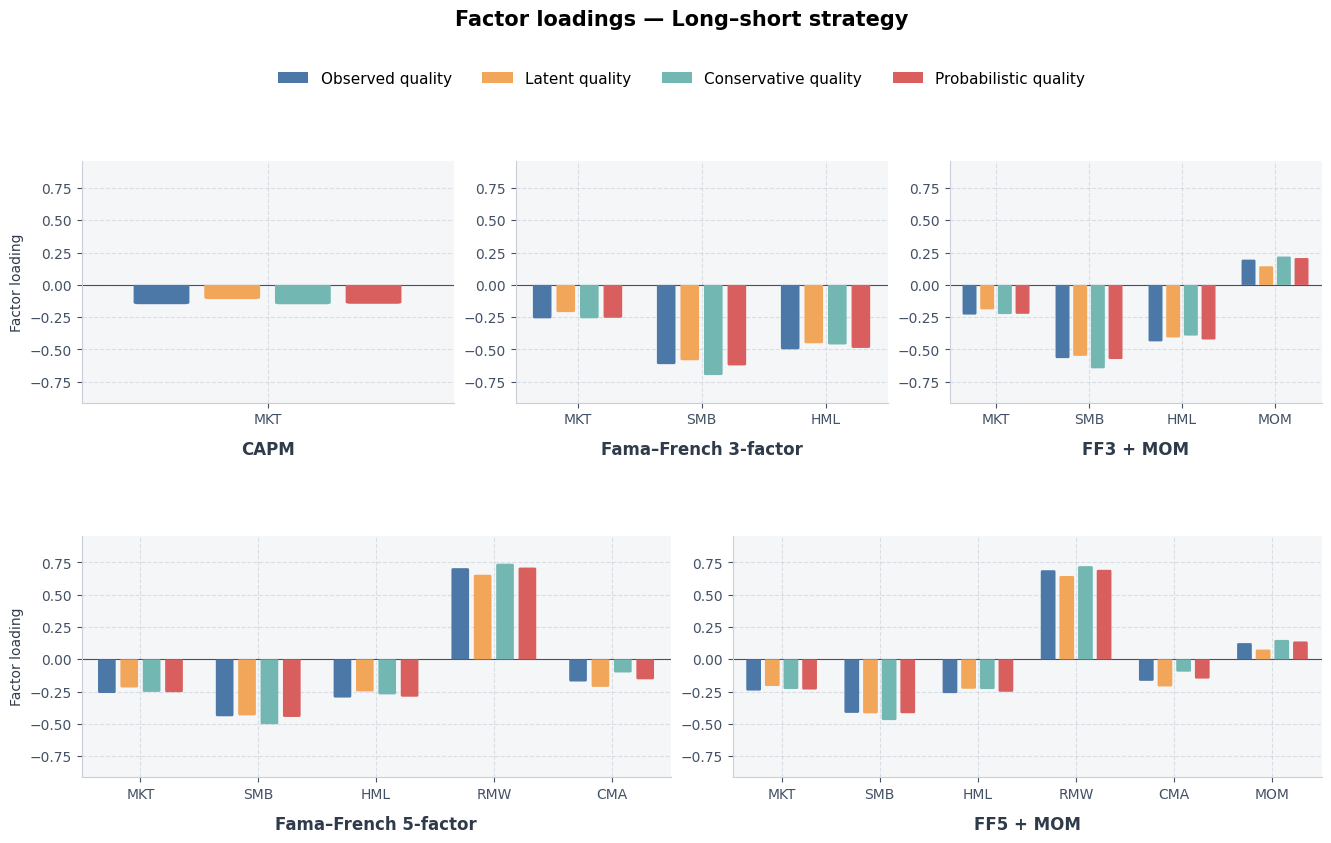

/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_99199/1961485977.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved to figure1_q5.pdf


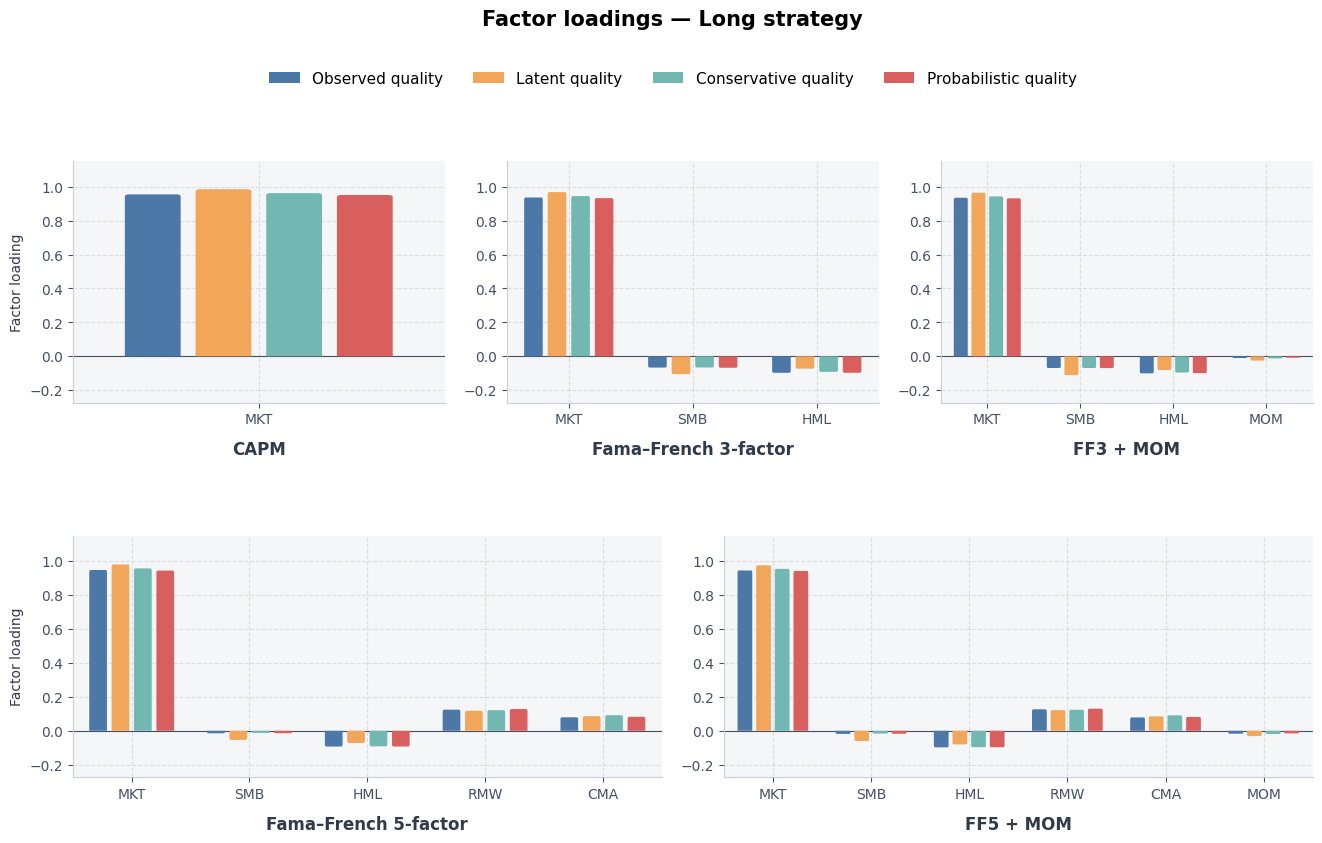

In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Patch

FACTOR_MODELS = {
    "CAPM":    ["MKT"],
    "FF3":     ["MKT", "SMB", "HML"],
    "FF3+MOM": ["MKT", "SMB", "HML", "MOM"],
    "FF5":     ["MKT", "SMB", "HML", "RMW", "CMA"],
    "FF5+MOM": ["MKT", "SMB", "HML", "RMW", "CMA", "MOM"],
}

PANEL_TITLES = {
    "CAPM":    "CAPM",
    "FF3":     "Fama–French 3-factor",
    "FF3+MOM": "FF3 + MOM",
    "FF5":     "Fama–French 5-factor",
    "FF5+MOM": "FF5 + MOM",
}

def draw_rounded_bar(ax, x, y, width, height, radius, color, zorder=3):
    if height == 0:
        return
    r = min(radius, width / 2 * 0.9, abs(height) / 2 * 0.9)
    if height > 0:
        verts = [
            (x,         y),
            (x + width, y),
            (x + width, y + height - r),
            (x + width, y + height),
            (x + width - r, y + height),
            (x + r,     y + height),
            (x,         y + height),
            (x,         y + height - r),
            (x,         y),
        ]
        codes = [
            Path.MOVETO, Path.LINETO,
            Path.LINETO, Path.CURVE3, Path.CURVE3,
            Path.LINETO, Path.CURVE3, Path.CURVE3,
            Path.CLOSEPOLY,
        ]
    else:
        verts = [
            (x,         y),
            (x + width, y),
            (x + width, y + height + r),
            (x + width, y + height),
            (x + width - r, y + height),
            (x + r,     y + height),
            (x,         y + height),
            (x,         y + height + r),
            (x,         y),
        ]
        codes = [
            Path.MOVETO, Path.LINETO,
            Path.LINETO, Path.CURVE3, Path.CURVE3,
            Path.LINETO, Path.CURVE3, Path.CURVE3,
            Path.CLOSEPOLY,
        ]
    patch = PathPatch(Path(verts, codes), facecolor=color,
                      edgecolor="none", zorder=zorder)
    ax.add_patch(patch)


def plot_factor_loadings(strategy, save_path=None):
    fig = plt.figure(figsize=(16, 8), facecolor="white")
    gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.55, wspace=0.4)

    axes = [
        fig.add_subplot(gs[0, 0:2]),
        fig.add_subplot(gs[0, 2:4]),
        fig.add_subplot(gs[0, 4:6]),
        fig.add_subplot(gs[1, 0:3]),
        fig.add_subplot(gs[1, 3:6]),
    ]

    sub = betas_df[betas_df["Strategy"] == strategy]
    ymin = sub["Beta"].min()
    ymax = sub["Beta"].max()
    pad  = (ymax - ymin) * 0.15
    ylim = (ymin - pad, ymax + pad)

    n_methods = len(METHODS)
    spacing   = 0.19
    bar_width = 0.15
    radius    = 0.012
    offsets   = np.linspace(
        -(n_methods - 1) / 2 * spacing,
         (n_methods - 1) / 2 * spacing,
         n_methods
    )

    for idx, (ax, (model_name, factors_list)) in enumerate(
            zip(axes, FACTOR_MODELS.items())):
        ax.set_facecolor("#f5f6f8")
        x = np.arange(len(factors_list))

        for i, method in enumerate(METHODS):
            row = betas_df[
                (betas_df["Strategy"] == strategy) &
                (betas_df["Method"]   == method) &
                (betas_df["Model"]    == model_name)
            ]
            betas = [row[row["Factor"] == f]["Beta"].values[0]
                     for f in factors_list]

            for j, beta in enumerate(betas):
                draw_rounded_bar(
                    ax,
                    x=x[j] + offsets[i] - bar_width / 2,
                    y=0,
                    width=bar_width,
                    height=beta,
                    radius=radius,
                    color=METHOD_COLORS[method],
                    zorder=3,
                )

        ax.axhline(0, color="#435165", linewidth=0.8, zorder=2)
        ax.set_xticks(x)
        ax.set_xticklabels(factors_list, fontsize=10)
        ax.set_xlim(-0.5, len(factors_list) - 0.5)
        ax.set_ylim(ylim)
        ax.set_title("")
        ax.set_xlabel(PANEL_TITLES[model_name], fontsize=12,
                      fontweight="bold", labelpad=10)
        ax.set_ylabel("Factor loading" if idx in [0, 3] else "", fontsize=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="y", labelsize=10)

    legend_handles = [
        Patch(facecolor=METHOD_COLORS[m], label=METHOD_LABELS[m])
        for m in METHODS
    ]
    fig.legend(legend_handles, [METHOD_LABELS[m] for m in METHODS],
               loc="upper center", bbox_to_anchor=(0.5, 1.01),
               ncol=4, fontsize=11, frameon=False)

    strategy_label = "Long–short" if strategy == "LongShort" else "Long"
    fig.suptitle(f"Factor loadings — {strategy_label} strategy",
                 fontsize=15, fontweight="bold", y=1.07)

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor="white")
        print(f"Saved to {save_path}")

    plt.show()


plot_factor_loadings("LongShort", save_path="figure1_longshort.pdf")
plot_factor_loadings("Q5",        save_path="figure1_q5.pdf")

In [8]:
import statsmodels.api as sm

ROLLING_MODELS = {
    "CAPM":    ["MKT"],
    "FF5+MOM": ["MKT", "SMB", "HML", "RMW", "CMA", "MOM"],
}

WINDOW = 24
rolling_results = []

for strategy in ["LongShort", "Q5"]:
    for method in METHODS:
        subset = df[
            (df["Method"] == method) &
            (df["PortfolioStrategy"] == strategy)
        ].sort_values("Date").reset_index(drop=True)

        for model_name, factors_list in ROLLING_MODELS.items():
            for end_idx in range(WINDOW - 1, len(subset)):
                window_data = subset.iloc[end_idx - WINDOW + 1 : end_idx + 1]
                X = sm.add_constant(window_data[factors_list])
                y = window_data["ExcessReturn"]
                res = sm.OLS(y, X).fit()

                rolling_results.append({
                    "Strategy": strategy,
                    "Method":   method,
                    "Model":    model_name,
                    "Date":     window_data["Date"].iloc[-1],
                    "Alpha":    res.params["const"] * 12,  # annualise
                })

rolling_df = pd.DataFrame(rolling_results)
print(rolling_df.shape)
print(rolling_df.head(8))
print("Date range:", rolling_df["Date"].min(), "to", rolling_df["Date"].max())

(2656, 5)
    Strategy                   Method Model       Date     Alpha
0  LongShort  Method1_ObservedQuality  CAPM 2012-06-30  0.283086
1  LongShort  Method1_ObservedQuality  CAPM 2012-07-31  0.310394
2  LongShort  Method1_ObservedQuality  CAPM 2012-08-31  0.277744
3  LongShort  Method1_ObservedQuality  CAPM 2012-09-30  0.261736
4  LongShort  Method1_ObservedQuality  CAPM 2012-10-31  0.246411
5  LongShort  Method1_ObservedQuality  CAPM 2012-11-30  0.221162
6  LongShort  Method1_ObservedQuality  CAPM 2012-12-31  0.233963
7  LongShort  Method1_ObservedQuality  CAPM 2013-01-31  0.248095
Date range: 2012-06-30 00:00:00 to 2026-03-31 00:00:00


/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_99199/99172385.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved to figure2_longshort.pdf


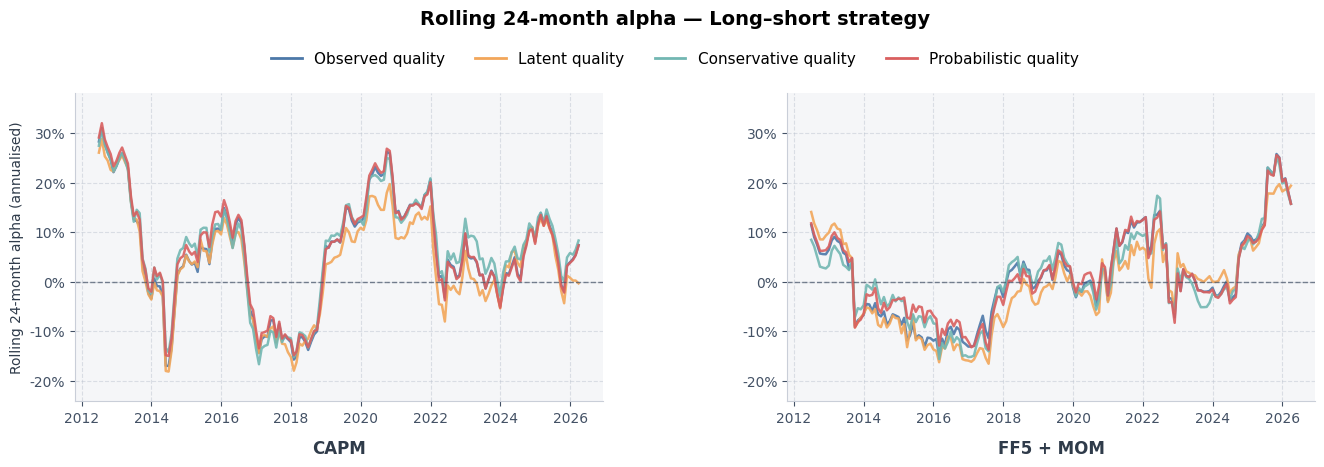

/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_99199/99172385.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved to figure2_q5.pdf


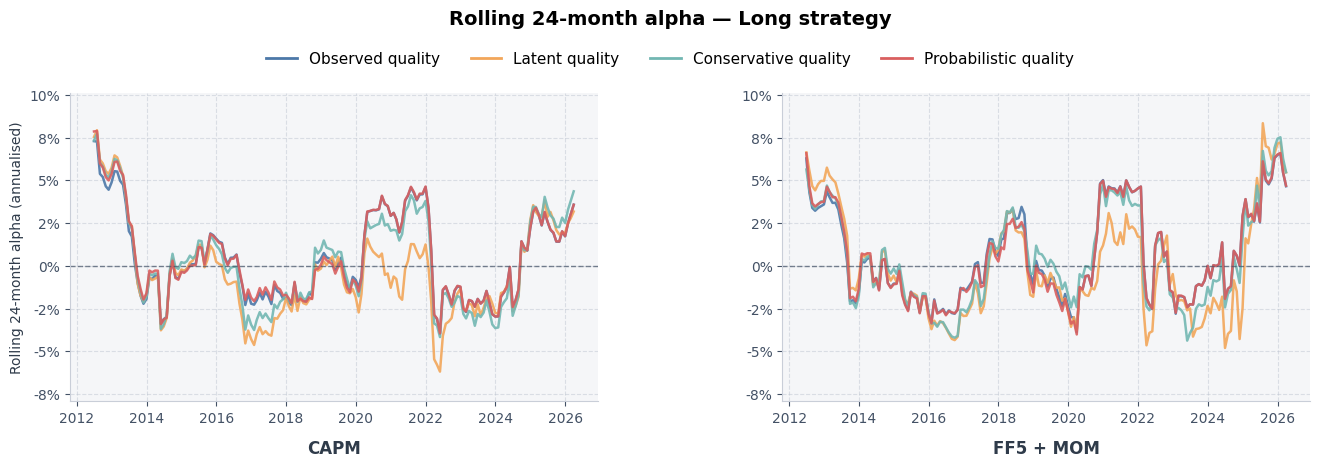

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_rolling_alpha(strategy, save_path=None):
    fig = plt.figure(figsize=(16, 4), facecolor="white")
    gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
    ]

    sub = rolling_df[rolling_df["Strategy"] == strategy]

    ymin = sub["Alpha"].min()
    ymax = sub["Alpha"].max()
    pad  = (ymax - ymin) * 0.12
    ylim = (ymin - pad, ymax + pad)

    model_titles = {
        "CAPM":    "CAPM",
        "FF5+MOM": "FF5 + MOM",
    }

    for ax, model_name in zip(axes, ["CAPM", "FF5+MOM"]):
        ax.set_facecolor("#f5f6f8")
        model_sub = sub[sub["Model"] == model_name]

        for method in METHODS:
            method_sub = model_sub[
                model_sub["Method"] == method
            ].sort_values("Date")

            ax.plot(
                method_sub["Date"],
                method_sub["Alpha"],
                color=METHOD_COLORS[method],
                label=METHOD_LABELS[method],
                linewidth=1.8,
                alpha=0.9,
            )

        ax.axhline(0, color="#435165", linewidth=1.0,
                   linestyle="--", zorder=2, alpha=0.7)

        ax.set_ylim(ylim)
        ax.set_title("")
        ax.set_xlabel(model_titles[model_name], fontsize=12,
                      fontweight="bold", labelpad=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", labelsize=10)
        ax.yaxis.set_tick_params(labelleft=True)
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%")
        )

    axes[0].set_ylabel("Rolling 24-month alpha (annualised)", fontsize=10)
    axes[1].set_ylabel("")

    handles = [
        plt.Line2D([0], [0], color=METHOD_COLORS[m],
                   linewidth=2, label=METHOD_LABELS[m])
        for m in METHODS
    ]
    fig.legend(handles, [METHOD_LABELS[m] for m in METHODS],
               loc="upper center", bbox_to_anchor=(0.5, 1.02),
               ncol=4, fontsize=11, frameon=False)

    strategy_label = "Long–short" if strategy == "LongShort" else "Long"
    fig.suptitle(f"Rolling 24-month alpha — {strategy_label} strategy",
                 fontsize=14, fontweight="bold", y=1.09)

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor="white")
        print(f"Saved to {save_path}")

    plt.show()

plot_rolling_alpha("LongShort", save_path="figure2_longshort.pdf")
plot_rolling_alpha("Q5",        save_path="figure2_q5.pdf")

/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_99199/830615091.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved to figure0_cumulative_returns.pdf


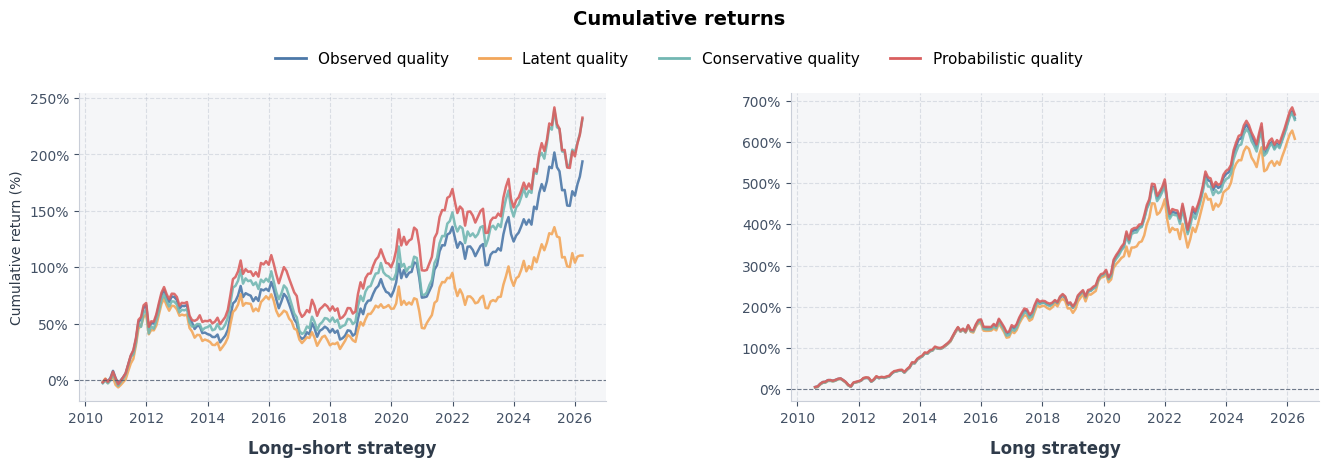

In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_cumulative_returns(save_path=None):
    fig = plt.figure(figsize=(16, 4), facecolor="white")  # white outer background
    gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
    ]

    strategy_map = {
        "LongShort": ("Long–short strategy", axes[0]),
        "Q5":        ("Long strategy",        axes[1]),
    }

    for strategy, (title, ax) in strategy_map.items():
        ax.set_facecolor("#f5f6f8") 
        for method in METHODS:
            subset = df[
                (df["Method"] == method) &
                (df["PortfolioStrategy"] == strategy)
            ].sort_values("Date").reset_index(drop=True)

            cumret = (1 + subset["Return"]).cumprod() - 1

            ax.plot(
                subset["Date"],
                cumret * 100,
                color=METHOD_COLORS[method],
                label=METHOD_LABELS[method],
                linewidth=1.8,
                alpha=0.9,
            )

        ax.axhline(0, color="#435165", linewidth=0.8,
                   linestyle="--", zorder=2, alpha=0.7)

        ax.set_title("")
        ax.set_xlabel(title, fontsize=12, fontweight="bold", labelpad=10)   
        ax.set_ylabel("Cumulative return (%)" if ax == axes[0] else "",
                      fontsize=10)
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x:.0f}%")
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", labelsize=10)

    handles = [
        plt.Line2D([0], [0], color=METHOD_COLORS[m],
                   linewidth=2, label=METHOD_LABELS[m])
        for m in METHODS
    ]
    fig.legend(handles, [METHOD_LABELS[m] for m in METHODS],
               loc="upper center", bbox_to_anchor=(0.5, 1.02),
               ncol=4, fontsize=11, frameon=False)

    fig.suptitle("Cumulative returns", fontsize=14,
                 fontweight="bold", y=1.09)

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor="white")  # ensure white background when saved
        print(f"Saved to {save_path}")

    plt.show()

plot_cumulative_returns(save_path="figure0_cumulative_returns.pdf")